# Explain the opposing effect of POI density vs. diversity

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
from scipy import stats
import geopandas as gpd
from scipy.stats import spearmanr
import networkx as nx
import igraph as ig
import statsmodels.api as sm

In [24]:
import matplotlib as mpl
from matplotlib import font_manager
import pathlib

font_dir = pathlib.Path.home() / "fonts"

for f in font_dir.glob("*.ttf"):
    font_manager.fontManager.addfont(str(f))

def setup_mpl():

    mpl.rcParams.update({

        # -------------------
        # Fonts (publication safe)
        # -------------------
        "font.family": "Liberation Sans",
        "font.size": 7,          # base text

        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,

        # keep text editable in SVG/PDF
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,

        # -------------------
        # Lines & axes
        # -------------------
        "lines.linewidth": 0.8,
        "axes.linewidth": 0.8,

        # -------------------
        # Ticks (Nature style thin & compact)
        # -------------------
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.minor.width": 0.6,
        "ytick.minor.width": 0.6,

        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 1.5,
        "ytick.minor.size": 1.5,

        "xtick.major.pad": 2,
        "ytick.major.pad": 2,

        "xtick.top": False,
        "ytick.right": False,

        # -------------------
        # Layout polish
        # -------------------
        "axes.labelpad": 2,
        "mathtext.default": "regular",
        "legend.frameon": False
    })


setup_mpl()

## 1. Load data

In [3]:
df = pd.read_csv("../data/cell_statistics_45_min.csv")
df['log_POI_density'] = np.log(df['POI density'] + 1e-6)
df['log_detour'] = np.log(df['detour'] + 1e-6)
df.dropna(inplace=True)
df.head()

,cell,detour,Empirical,Residential,threshold,Theoretical,Country,correct_name,bb_e,bb_t,...,pop,wm_duration_min,wm_length_m,Number of POI,Number of Unique Categories,Entropy,Gini,POI density,log_POI_density,log_detour
0,874995b86ffffff,1.210166,9.949130,12.554252,45 min,11.706087,mexico,Greater Mexico City,2.605122,0.848165,...,86480.771429,45.253772,0.365647,390.0,26.0,3.693287,0.875411,0.004510,-5.401309,0.190758
1,874995bb1ffffff,1.223314,10.172453,8.820479,45 min,10.781191,mexico,Greater Mexico City,-1.351973,-1.960712,...,85872.885714,43.445370,0.355938,444.0,23.0,3.741544,0.900252,0.005170,-5.264605,0.201564
2,874995ba6ffffff,1.207564,8.292169,6.710177,45 min,9.559123,mexico,Greater Mexico City,-1.581992,-2.848946,...,89520.742857,52.252239,2.344003,804.0,26.0,4.080531,0.923266,0.008981,-4.712515,0.188606
3,874995ba2ffffff,1.208923,9.137159,8.479541,45 min,10.119233,mexico,Greater Mexico City,-0.657618,-1.639692,...,83972.825000,46.948280,0.377496,680.0,24.0,4.075617,0.927288,0.008098,-4.816032,0.189731
4,874995bb5ffffff,1.241095,8.733309,8.058673,45 min,10.156311,mexico,Greater Mexico City,-0.674637,-2.097638,...,88536.475000,57.034581,2.180986,419.0,26.0,4.080046,0.925718,0.004733,-5.353088,0.215995


## 2. Flow

In [5]:
df.groupby('Country')[['Entropy', 'Residential']].median()

,Entropy,Residential
Country,,
india,3.471354,21.399117
mexico,3.240320,27.032259


In [6]:
pop_dict = dict(zip(df['cell'], df['pop']))

In [ ]:
gdf = gpd.read_file('/work/netmob24/data/cities/cities.geojson')
gdf = gdf[gdf['country'] != "colombia"]
cells2keep = gdf["cell"].unique()

def compute_entropy(end_h3_series, weight_series):
    """
    Compute entropy of end_h3_7 destinations weighted by trip_count.
    Returns a scalar (float).
    """
    # Aggregate weights by unique destination cells
    w = (
        pd.DataFrame({"end": end_h3_series, "w": weight_series})
        .groupby("end")["w"]
        .sum()
    )

    # Convert to probabilities
    p = w / w.sum()

    # Standard Shannon entropy (in nats)
    entropy = -np.sum(p * np.log(p))

    return float(entropy)

def compute_igraph_centrality(df_od, source_col="start_h3_7", target_col="end_h3_7",
                              weight_col="trip_count"):
    """
    Build a directed weighted graph from OD flows and compute:
    - in-strength
    - PageRank
    - Betweenness centrality (weighted)
    """

    # ----------------------------------------------------------
    # 1. Build mapping from cell IDs to 0..N-1
    # ----------------------------------------------------------
    nodes = pd.Index(pd.concat([df_od[source_col], df_od[target_col]]).unique())
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    N = len(nodes)

    # ----------------------------------------------------------
    # 2. Convert OD table to edge list
    # ----------------------------------------------------------
    df_edges = df_od[[source_col, target_col, weight_col]].copy()
    df_edges["source"] = df_edges[source_col].map(node_to_idx)
    df_edges["target"] = df_edges[target_col].map(node_to_idx)
    df_edges["weight"] = df_edges[weight_col].astype(float)

    edges = list(zip(df_edges["source"], df_edges["target"]))
    weights = df_edges["weight"].values

    # ----------------------------------------------------------
    # 3. Build igraph graph
    # ----------------------------------------------------------
    g = ig.Graph(n=N, edges=edges, directed=True)
    g.es["weight"] = weights

    # ----------------------------------------------------------
    # 4. Centrality measures
    # ----------------------------------------------------------

    # (a) Weighted in-strength (sum of incoming weights)
    in_strength = g.strength(mode="in", weights="weight")

    # (b) PageRank (weighted, directed)
    pagerank = g.pagerank(weights="weight", directed=True, damping=0.85)

    # (c) Betweenness centrality (weighted shortest paths)
    #     igraph treats weights as distances, so we invert them
    inv_weights = 1 / (weights + 1e-6)
    g.es["inv_weight"] = inv_weights
    betweenness = g.betweenness(weights="inv_weight", directed=True)

    # ----------------------------------------------------------
    # 5. Return DataFrame aligned with H3 cell IDs
    # ----------------------------------------------------------
    cent_df = pd.DataFrame({
        "start_h3_7": nodes,
        "in_strength": in_strength,
        "pagerank": pagerank,
        "betweenness": betweenness
    })

    return cent_df


# Load OD data (keep trip duration and length)
def get_weekly_data(countryID=None):
    df1 = pd.read_csv(f"/work/netmob24/data/OD/weekly/H37/od_week_h37_{countryID}_2019.csv")
    df2 = pd.read_csv(f"/work/netmob24/data/OD/weekly/H37/od_week_h37_{countryID}_2020.csv")
    # Keep only pre-covid data
    df2 = df2[df2["week_number"] < 10] # Only keep the first 10 weeks (pre-covid)
    df = pd.concat([df1, df2], ignore_index=True)

    # Focus on cities
    df = df[df["start_h3_7"].isin(cells2keep)]
    # Consider trips outside the focal cell
    df = df[df["end_h3_7"] != df["start_h3_7"]]

    cent_df = compute_igraph_centrality(df, source_col="start_h3_7", target_col="end_h3_7", weight_col="trip_count")

    # Group and compute weighted medians
    result = df.groupby('start_h3_7').apply(
        lambda g: pd.Series({
            'total_trips': (lambda p: g["trip_count"].sum() / p if p else np.nan) (pop_dict.get(g.name)),
            'end_cell_entropy': compute_entropy(g['end_h3_7'], g['trip_count'])
        }), include_groups=False
    ).reset_index()
    result = result.merge(cent_df, on='start_h3_7', how='left')
    return result.rename(columns={"start_h3_7": "cell"})

df_od_list = []
for countryID in ("in", "mx"):
    df_od = get_weekly_data(countryID=countryID)
    df_od.loc[:, "Country"] = "india" if countryID == "in" else "mexico"
    df_od_list.append(df_od)
df_od = pd.concat(df_od_list, ignore_index=True)
df_od.head()

## 3. Transport related POIs

In [9]:
transport_categories = [
    # ----- Public Transport -----
    "public_transportation",
    "transportation",
    "bus_station",
    "bus_service",
    "bus_rentals",
    "bus_tours",
    "train_station",
    "airport",
    "airlines",
    "airline",
    "airport_terminal",
    "airport_lounge",
    "airport_shuttles",
    "heliports",
    "seaplane_bases",
    "ferry_boat_company",

    # ----- Taxi / Ridehailing / Shuttle -----
    "taxi_service",
    "taxi_rank",
    "ride_sharing",
    "shuttle_bus_service",   # inferred category
    "transportation_service",  # inferred umbrella

    # ----- Parking / Vehicle Access -----
    "parking",
    "garage",                      # repair / parking-related
    "car_wash",
    "gas_station",
    "truck_gas_station",
    "rest_areas",

    # ----- Car Services / Dealerships / Rentals -----
    "car_dealer",
    "car_rental_agency",
    "automotive_repair",
    "automotive_services_and_repair",
    "auto_body_shop",
    "auto_parts_and_supply_store",
    "auto_restoration_services",
    "auto_company",
    "automotive_dealer",
    "automotive_parts_and_accessories",
    "car_stereo_store",
    "car_window_tinting",
    "car_customization",
    "motorcycle_dealer",
    "motorcycle_manufacturer",
    "motorcycle_rentals",
    "motorcycle_repair",
    "motorsport_vehicle_dealer",
    "truck_dealer",
    "truck_rentals",
    "truck_repair",
    "boat_dealer",
    "boat_rental_and_training",
    "boat_parts_and_accessories",
    "boat_service_and_repair",

    # ----- Logistics / Freight / Shipping -----
    "freight_and_cargo_service",
    "freight_forwarding_agency",
    "railroad_freight",
    "shipping_center",
    "shipping_collection_services",
    "delivery_service",
    "courier_and_delivery_services",
    "vehicle_shipping",

    # ----- Mobility Activities / Vehicle Use -----
    "bike_rentals",
    "bike_repair_maintenance",
    "bicycle_shop",
    "canoe_and_kayak_hire_service",
    "paddleboarding_center",
    "surf_shop",
    "jet_skis_rental",
    "atv_rentals_and_tours",
    "boat_tours",
    "fishing_charter",

    # ----- Transport Infrastructure -----
    "bridge",
    "pier",
    "quay",
    "harbor",          # inferred
    "transport_hub",   # inferred
    "terminal",        # inferred

    # ----- Vehicle Inspections / Licensing -----
    "department_of_motor_vehicles",
    "emissions_inspection",
    "automobile_registration_service",

    # ----- Auto Insurance / Finance -----
    "auto_insurance",
    "insurance_agency",    # mixed but often used for auto
    "car_loan",            # inferred
]

In [10]:
poi_counts_list = []
for country in ['india', 'mexico']:
    print(f"Processing POIs for {country.upper()}")
    gdf_poi = gpd.read_parquet(f'../data/pois/pois_{country}.geoparquet')
    gdf_poi = gdf_poi.loc[gdf_poi['confidence'] > 0.9, ['id', 'categories', 'geometry']].copy()
    gdf_poi.loc[:, 'primary'] = gdf_poi['categories'].apply(lambda x: x['primary'] if x is not None else None)
    print("Total number of POIs", len(gdf_poi))
    gdf_poi = gdf_poi[gdf_poi['primary'].isin(transport_categories)]
    print("Transport related:", len(gdf_poi))
    gdf = gdf.to_crs(3857)
    gdf_poi = gdf_poi.to_crs(3857)
    joined = gpd.sjoin(
        gdf,
        gdf_poi[['geometry', 'primary']],
        how="left",
        predicate="contains"
    )
    poi_counts = (
        joined.groupby("cell")["primary"]
        .count()
        .reset_index(name="transport_poi_count")
    )
    poi_counts_list.append(poi_counts)
poi_counts = pd.concat(poi_counts_list, ignore_index=True)

Processing POIs for INDIA
Total number of POIs 308288
Transport related: 14923
Processing POIs for MEXICO
Total number of POIs 943340
Transport related: 65911


## 4. Road network centrality

In [11]:
# Load the graph
g = ig.Graph.Read_GML("../data/network/mexico_hexagons_driving.gml")

# --- Inspect vertex attributes ---
print("\nVertex attributes:", g.vs.attributes())

# --- Inspect edge attributes ---
print("\nEdge attributes:", g.es.attributes())

# Peek first 5 edges
print("\nExample edges:")
for e in g.es[:5]:
    print(e.tuple, e.attributes())


Vertex attributes: ['id', 'label']

Edge attributes: ['weight']

Example edges:
(0, 1) {'weight': 3906.6364682574917}
(0, 2) {'weight': 8598.328687208068}
(0, 3) {'weight': 6274.992293111979}
(0, 4) {'weight': 6555.018442448455}
(0, 5) {'weight': 5961.440138673574}


## 5. OLS modeling to understand POI density vs. diversity

In [12]:
ols_holder = []

### High-entropy area

In [13]:
df2m = df.merge(df_od.drop(columns=['Country']), on="cell", how="left")
df2m = df2m.merge(poi_counts, on="cell", how="left")
df2m['transport_poi_count'].fillna(0, inplace=True)
df2m.loc[:, 'pop'] = df2m['cell'].map(pop_dict)
df2m.dropna(subset=['pop'], inplace=True)
df2m.loc[:, 'transport_poi_count'] = df2m['transport_poi_count'] / df2m['pop']

threshold_dict ={'india': {'Residential': 21, 'Entropy': 3.5},
                 'mexico': {'Residential': 27, 'Entropy': 3.2}}
for country in ['india', 'mexico']:
    hi_dep_lo_ent = df2m[
        (df2m['Country'] == country) &
        # (df2m['Residential'] > threshold_dict[country]['Residential']) &
        (df2m['Entropy'] >= threshold_dict[country]['Entropy']) &
        (df2m['threshold'] == '45 min')
    ].copy()
    hi_dep_lo_ent.dropna(inplace=True)

    # OLS with basic controls
    X = hi_dep_lo_ent[['Entropy', 'Residential', 'total_trips', 'transport_poi_count']] # , 'pagerank'
    X = sm.add_constant(X)
    y = hi_dep_lo_ent['log_POI_density']
    ols = sm.OLS(y, X).fit(cov_type='HC3')
    ols_holder.append(ols)
    print(f"OLS results for {country.upper()}:")
    print(ols.summary().tables[1])
    print("\n\n")

OLS results for INDIA:
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 -10.0700      0.265    -37.967      0.000     -10.590      -9.550
Entropy                 0.7587      0.069     10.930      0.000       0.623       0.895
Residential             0.0027      0.002      1.754      0.079      -0.000       0.006
total_trips             2.3129      0.083     27.935      0.000       2.151       2.475
transport_poi_count  1949.0422    216.445      9.005      0.000    1524.818    2373.266



OLS results for MEXICO:
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 -12.0560      0.213    -56.490      0.000     -12.474     -11.638
Entropy                 1.4440      0.059     24.616      0.000       

/tmp/ipykernel_142494/772481870.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2m['transport_poi_count'].fillna(0, inplace=True)
/tmp/ipykernel_142494/772481870.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.         0.00019658 0.         ... 0.         0.         0.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df2m.loc[:, 'transport_poi_count'] = df2m['transport_poi_count'] / df2m['pop']

### Low-entropy area

In [14]:
for country in ['india', 'mexico']:
    hi_dep_lo_ent = df2m[
        (df2m['Country'] == country) &
        # (df2m['Residential'] > threshold_dict[country]['Residential']) &
        (df2m['Entropy'] < threshold_dict[country]['Entropy']) &
        (df2m['threshold'] == '45 min')
    ].copy()
    hi_dep_lo_ent.dropna(inplace=True)

    # OLS with basic controls
    X = hi_dep_lo_ent[['Entropy', 'Residential', 'total_trips', 'transport_poi_count']] # , 'pagerank'
    X = sm.add_constant(X)
    y = hi_dep_lo_ent['log_POI_density']
    ols = sm.OLS(y, X).fit(cov_type='HC3')
    ols_holder.append(ols)
    print(f"OLS results for {country.upper()}:")
    print(ols.summary().tables[1])
    print("\n\n")

OLS results for INDIA:
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 -10.5927      0.118    -89.883      0.000     -10.824     -10.362
Entropy                 0.8358      0.038     22.052      0.000       0.761       0.910
Residential             0.0075      0.002      3.939      0.000       0.004       0.011
total_trips             3.5902      0.259     13.844      0.000       3.082       4.099
transport_poi_count  3808.8511    563.585      6.758      0.000    2704.245    4913.457





OLS results for MEXICO:
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 -10.8064      0.129    -83.601      0.000     -11.060     -10.553
Entropy                 1.0257      0.036     28.779      0.000       0.956       1.096
Residential             0.0139      0.003      5.451      0.000       0.009       0.019
total_trips             1.2909      0.138      9.382      0.000       1.021       1.561
transport_poi_count  1756.7436    422.312      4.160      0.000     929.028    2584.459





## 6. Visualize the coefficients of OLS

In [15]:
from scipy.stats import norm

def extract_ols_effects_simple(ols, regime_label, country):
    """
    Convert statsmodels OLS results into clean effects dataframe
    for selected variables only.
    """

    coef = ols.params
    se = ols.bse
    pvals = ols.pvalues

    z = norm.ppf(0.975)

    df = pd.DataFrame({
        "Variable": coef.index,
        "Coefficient": coef.values,
        "StdErr": se.values,
        "Lower": coef - z * se,
        "Upper": coef + z * se,
        "p_value": pvals.values,
        "Regime": regime_label,
        "Country": country
    })

    # Keep only the variables of interest
    df = df[df["Variable"].isin(["total_trips", "transport_poi_count"])]

    # Clean names for plotting
    df["Variable"] = df["Variable"].map({
        "total_trips": "Total trips",
        "transport_poi_count": "Transport POIs (per cap.)"
    })

    return df.reset_index(drop=True)

ols_high_india, ols_high_mexico, ols_low_india, ols_low_mexico = ols_holder[0], ols_holder[1], ols_holder[2], ols_holder[3]

effects_ols = pd.concat([
    extract_ols_effects_simple(ols_low_india,  "Low", "india"),
    extract_ols_effects_simple(ols_high_india, "High", "india"),
    extract_ols_effects_simple(ols_low_mexico, "Low", "mexico"),
    extract_ols_effects_simple(ols_high_mexico,"High","mexico")
], ignore_index=True)

In [16]:
effects_ols['Variable'] = effects_ols['Variable'].map({"Total trips": "No. of trips\n/capita", "Transport POIs (per cap.)": "No. of transport\nPOIs /capita"})

In [28]:
def plot_ols_entropy_contrast_panels(effects_ols, country):

    df = effects_ols[effects_ols["Country"] == country].copy()

    # Two variables → two panels
    var_panels = [
        "No. of trips\n/capita",
        "No. of transport\nPOIs /capita"
    ]

    # Country-specific base color
    base_colors = {
        "india": "#ca6929",
        "mexico": "#3c693a"
    }
    base = base_colors[country.lower()]

    # Lighter/darker for regimes
    palette = {
        "Low": sns.light_palette(base, n_colors=3)[1],
        "High": sns.dark_palette(base, n_colors=3)[1]
    }

    fig, axes = plt.subplots(1, 2, figsize=(80/25.4, 40/25.4), sharey=False)
    y_label_flag = 1

    for ax, variable in zip(axes, var_panels):

        df_sub = df[df["Variable"] == variable].copy()

        # ---- POINTS ----
        sns.pointplot(
            data=df_sub,
            x="Regime",
            y="Coefficient",
            order=["Low", "High"],
            palette=palette,
            dodge=False,
            join=False,
            ax=ax,
            markersize=4
        )

        # ---- CI ----
        for _, row in df_sub.iterrows():
            x_pos = ["Low", "High"].index(row["Regime"])

            ax.plot(
                [x_pos, x_pos],
                [row["Lower"], row["Upper"]],
                color=palette[row["Regime"]],
                linewidth=1.4
            )

        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_xlim(-0.5, 1.5)
        sns.despine(ax=ax)

        if y_label_flag == 1:
            ax.set_ylabel("Coeff. on POI density")
            y_label_flag = 0
        else:
            ax.set_ylabel("")

        # ✅ REMOVE individual x-labels
        ax.set_xlabel("")

        ax.set_title(variable)
        ax.tick_params(axis="y")

        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # ✅ ADD ONE SHARED X-AXIS LABEL (CENTERED)
    fig.supxlabel("POI entropy regime", y=0.02)

    # ✅ Left-aligned country title
    fig.suptitle(country.capitalize())

    plt.tight_layout(pad=0.6)
    fig.savefig(f"../figures/density_ols_coef_{country}.pdf", dpi=600)
    plt.show()

/tmp/ipykernel_142494/3389499156.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(
/tmp/ipykernel_142494/3389499156.py:32: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/tmp/ipykernel_142494/3389499156.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(
/tmp/ipykernel_142494/3389499156.py:32: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


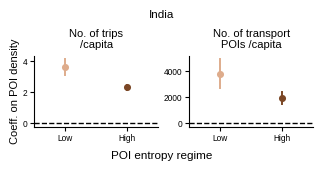

/tmp/ipykernel_142494/3389499156.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(
/tmp/ipykernel_142494/3389499156.py:32: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/tmp/ipykernel_142494/3389499156.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(
/tmp/ipykernel_142494/3389499156.py:32: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


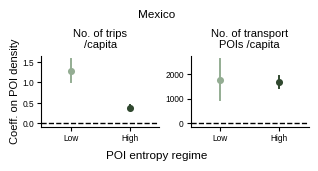

In [29]:
plot_ols_entropy_contrast_panels(effects_ols, country="india")
plot_ols_entropy_contrast_panels(effects_ols, country="mexico")